# Objective
This project aims to identify the key factors associated with young people's anxiety about their future careers, using data from the ASPIRES3 longitudinal study (N = 7,635). By applying exploratory data analysis, correlation analysis, and linear regression, we seek to uncover which psychological, social, and demographic variables most strongly predict future concern. The ultimate goal is to translate these findings into actionable recommendations for edtech companies, enabling them to design evidence‑based interventions that reduce student uncertainty and support career readiness.


# 1. Import Libraries and Database

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

df_full = pd.read_table('/kaggle/input/datasets/robinhuang87/aspire-survey/aspires3_survey.tab')
df_full.head()

,DOBSCREEN,DOBSCREEN2,RES,GENDER,AGE,ETH,ETH_BBRI,ETH_CAR,ETH_AFR,ETH_OTHB,...,stemdeg_07,stemdeg_08,stemdeg_09,stemdeg_10,stemdeg_11,studying,curr_deg_level,comp_deg_level,level,type
0,999,4,1,2,999,7,999,999,999,999,...,0,1,0,0,0,997,997,999,996,999
1,1,999,1,1,999,1,0,1,0,0,...,0,0,0,0,1,1,1,999,1,997
2,1,999,1,2,999,3,999,999,999,999,...,996,996,996,996,996,1,1,999,1,997
3,1,999,1,1,999,4,999,999,999,999,...,0,0,0,1,0,1,1,997,1,997
4,999,4,1,1,999,3,999,999,999,999,...,0,0,0,0,1,1,2,1,3,1


# 2. Replace 998 and 999 Values with NaN 

In [2]:
df_full.replace([998, 999], np.nan, inplace=True)

In [3]:

missing_percent = df_full.isna().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print(missing_percent.head(20))

AGE                100.000000
ACA_QUAL_07_SCH     99.502292
ACA_QUAL_10_SCH     99.502292
ACA_QUAL_09_SCH     99.502292
ACA_QUAL_08_SCH     99.502292
ACA_QUAL_05_SCH     99.502292
ACA_QUAL_01_SCH     99.502292
ACA_QUAL_04_SCH     99.502292
ACA_QUAL_03_SCH     99.502292
ACA_QUAL_02_SCH     99.502292
FUTJOB_TRAIN        99.502292
RIGHT_DEC_SCH       99.502292
ACA_QUAL_06_SCH     99.502292
ACA_QUAL_03_OTH     99.187950
ACA_QUAL_04_OTH     99.187950
ACA_QUAL_02_OTH     99.187950
ACA_QUAL_05_OTH     99.187950
ACA_QUAL_09_OTH     99.187950
ACA_QUAL_06_OTH     99.187950
RIGHT_DEC_EDU       99.187950
dtype: float64


# 3. Drop Columns with NaN value more than 50%

In [4]:
threshold = 50
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >{threshold}% missing.")

df_filtered = df_full.drop(columns=cols_to_drop)

Dropping 404 columns with >50% missing.


# 4. Check Target column 'Concern' is not dropped and is numeric

In [5]:
if 'CONCERN' in df_filtered.columns:
    df_filtered['CONCERN_R'] = 6 - df_filtered['CONCERN']
else:
    print("Warning: CONCERN column not found!")

# 5. Compute Association between Collumns and target (CONCERN_R)

In [6]:
#Compute association using pearson_r for numerical or ANOVA for categorical
def get_association(df, target, col):
    data = df[[col, target]].dropna()
    if len(data) < 10:
        return ('too_few', np.nan, np.nan, len(data))
    
    x = data[col]
    y = data[target]
    
    
    if pd.api.types.is_numeric_dtype(x):
        r, p = stats.pearsonr(x, y)
        return ('pearson_r', r, p, len(data))
    else:
        groups = [y[x == cat] for cat in x.unique()]
        if any(len(g) < 2 for g in groups):
            return ('cat_too_small', np.nan, np.nan, len(data))
        f_stat, p_val = stats.f_oneway(*groups)
        ss_between = sum(len(g) * (g.mean() - y.mean())**2 for g in groups)
        ss_total = sum((y - y.mean())**2)
        eta_sq = ss_between / ss_total if ss_total != 0 else 0
        return ('eta_sq', eta_sq, p_val, len(data))


In [7]:
results = []
for col in df_filtered.columns:
    if col in ['CONCERN_R', 'CONCERN']:
        continue
    measure, value, p, n = get_association(df_filtered, 'CONCERN_R', col)
    results.append({
        'column': col,
        'measure': measure,
        'value': value,
        'p_value': p,
        'n': n
    })

results_df = pd.DataFrame(results)
results_df['abs_value'] = results_df['value'].abs()
results_df = results_df.sort_values('abs_value', ascending=False).drop('abs_value', axis=1)

print(results_df.head(20))

/tmp/ipykernel_17/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_17/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_17/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_17/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)


             column    measure     value        p_value     n
190       COVID_ASP  pearson_r -0.391318  8.886652e-272  7467
331         LIFESAT  pearson_r -0.336065  3.536348e-197  7491
148         JOBPER1  pearson_r  0.284129   1.280322e-80  4298
191     CONF_FUTJOB  pearson_r  0.283092  7.663460e-138  7479
193     CAR_SAT_EMP  pearson_r  0.274958   2.452683e-79  4527
358            PHQ2  pearson_r  0.272423  2.901279e-127  7471
154         JOBPER7  pearson_r -0.272062   9.172062e-74  4295
149         JOBPER2  pearson_r  0.266073   1.402004e-70  4299
356            GAD2  pearson_r  0.261324  7.989392e-117  7466
357            PHQ1  pearson_r  0.260215  8.130500e-116  7466
355            GAD1  pearson_r  0.256865  5.573944e-113  7478
187  RIGHT_DEC_WORK  pearson_r  0.249836   3.311394e-62  4301
152         JOBPER5  pearson_r  0.243709   3.890360e-59  4297
151         JOBPER4  pearson_r  0.240623   1.157237e-57  4298
198   NO_CAR_RES_05  pearson_r -0.234491   1.580514e-61  4846
173     

/tmp/ipykernel_17/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)
/tmp/ipykernel_17/2119592144.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x, y)


# 6. Create Separate table for top 20 collumns with highest association value and check for initial OLS regression and VIF 

In [8]:
top20_cols = [
    'COVID_ASP',
    'LIFESAT',
    'JOBPER1',
    'CONF_FUTJOB',
    'CAR_SAT_EMP',
    'PHQ2',
    'JOBPER7' ,
    'JOBPER2',
    'GAD2',
    'PHQ1',
    'GAD1',
    'RIGHT_DEC_WORK',
    'JOBPER5',
    'JOBPER4',
    'NO_CAR_RES_05',
    'PREV_PG_02',
    'BROAD',
    'NO_CAR_RES_01',
    'BELONG',
    'NO_CAR_RES_03'
             
]

In [9]:
# List of demographic columns you want to add
demographic_cols = ['GENDER', 'parent_uni', 'REGION', 'ETH']

# Add CONCERN_R to the list
cols_to_keep = top20_cols + demographic_cols + ['CONCERN_R']

# Check which columns exist in df_filtered
existing_cols = [col for col in cols_to_keep if col in df_filtered.columns]
print(f"Keeping {len(existing_cols)} columns: {existing_cols}")

# Create subset
df_top20 = df_filtered[existing_cols].copy()

Keeping 24 columns: ['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'PHQ2', 'JOBPER7', 'JOBPER2', 'GAD2', 'PHQ1', 'GAD1', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03', 'GENDER', 'REGION', 'ETH', 'CONCERN_R']


In [10]:
df_top20.head()

,COVID_ASP,LIFESAT,JOBPER1,CONF_FUTJOB,CAR_SAT_EMP,PHQ2,JOBPER7,JOBPER2,GAD2,PHQ1,...,NO_CAR_RES_05,PREV_PG_02,BROAD,NO_CAR_RES_01,BELONG,NO_CAR_RES_03,GENDER,REGION,ETH,CONCERN_R
0,3.0,8.0,NaN,2.0,NaN,1.0,NaN,NaN,1.0,1.0,...,NaN,0,3.0,NaN,3.0,NaN,2.0,6.0,7.0,3.0
1,3.0,6.0,NaN,3.0,NaN,1.0,NaN,NaN,1.0,2.0,...,NaN,1,3.0,NaN,5.0,NaN,1.0,8.0,1.0,2.0
2,3.0,8.0,NaN,2.0,NaN,1.0,NaN,NaN,2.0,2.0,...,NaN,0,2.0,NaN,3.0,NaN,2.0,8.0,3.0,2.0
3,2.0,4.0,NaN,2.0,NaN,2.0,NaN,NaN,3.0,3.0,...,NaN,0,3.0,NaN,3.0,NaN,1.0,4.0,4.0,4.0
4,2.0,7.0,NaN,2.0,NaN,3.0,NaN,NaN,4.0,2.0,...,0.0,1,3.0,1.0,3.0,1.0,1.0,2.0,3.0,5.0


In [11]:
for col in top20_cols:
    if col in df_top20.columns and pd.api.types.is_categorical_dtype(df_top20[col]):
        df_top20[col + '_num'] = df_top20[col].cat.codes.replace(-1, np.nan)

/tmp/ipykernel_17/1336422587.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col in df_top20.columns and pd.api.types.is_categorical_dtype(df_top20[col]):


In [12]:
predictors = []
for col in top20_cols:
    if col + '_num' in df_top20.columns:
        predictors.append(col + '_num')
    elif col in df_top20.columns and pd.api.types.is_numeric_dtype(df_top20[col]):
        predictors.append(col)
    else:
        print(f"Skipping {col} – not numeric and no _num version")

In [13]:
print("Predictors:", predictors)

Predictors: ['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'PHQ2', 'JOBPER7', 'JOBPER2', 'GAD2', 'PHQ1', 'GAD1', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03']


In [14]:


# Drop rows with missing on any predictor or outcome
df_model = df_top20[predictors + ['CONCERN_R']].dropna()
X = df_model[predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model_all = sm.OLS(y, X).fit()
print(model_all.summary())

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     102.3
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          3.73e-320
Time:                        07:02:58   Log-Likelihood:                -4087.1
No. Observations:                3028   AIC:                             8216.
Df Residuals:                    3007   BIC:                             8342.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8320      0.156     24.

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

          Variable        VIF
0            const  84.415527
1        COVID_ASP   1.093446
2          LIFESAT   1.701411
3          JOBPER1   1.760643
4      CONF_FUTJOB   1.408456
5      CAR_SAT_EMP   1.773427
6             PHQ2   2.605981
7          JOBPER7   1.129737
8          JOBPER2   1.932353
9             GAD2   2.800668
10            PHQ1   2.158358
11            GAD1   2.649981
12  RIGHT_DEC_WORK   1.287603
13         JOBPER5   1.260709
14         JOBPER4   1.324801
15   NO_CAR_RES_05   1.204979
16      PREV_PG_02   1.149937
17           BROAD   1.066967
18   NO_CAR_RES_01   1.107557
19          BELONG   1.434190
20   NO_CAR_RES_03   1.114134


Result:
1. Model Fit
The linear regression model with 20 predictors explains 40.5% of the variance in future concern (CONCERN_R). This is a substantial effect size in survey‑based research and indicates that the selected variables collectively capture a meaningful portion of student anxiety.

2. Multicollinearity (VIF)
All variance inflation factors (VIF) were below 5, with most below 3. This confirms that multicollinearity is not a concern in the current model. The predictors contribute independent information, and coefficient estimates are stable.

3. Significant Predictors (p < 0.05):
COVID_ASP, LIFESAT, JOBPER1, CONF_FUTJOB, JOBPER7, RIGHT_DEC_WORK, JOBPER5, NO_CAR_RES_05, PREV_PG_02, BROAD, NO_CAR_RES_01, NO_CAR_RES_03

4. Non‑significant Predictors (p ≥ 0.05)
CAR_SAT_EMP, PHQ2, JOBPER2, GAD2, PHQ1 (borderline), GAD1 (borderline), JOBPER4, BELONG


# 7. Model Refinement: Backward Elimination of Non‑Significant Predictors

## 7.1 Creating a Mental Health Composite

### 7.1.1  Check Internal Consistency (Cronbach’s Alpha)

In [16]:

items_num = ['PHQ1', 'PHQ2', 'GAD1', 'GAD2']


existing_items = [col for col in items_num if col in df_top20.columns]
print(f"Numeric items available: {existing_items}")

Numeric items available: ['PHQ1', 'PHQ2', 'GAD1', 'GAD2']


In [17]:

df_alpha = df_top20[existing_items].dropna()


def cronbach_alpha(df):
   
    item_scores = df.values
    n_items = df.shape[1]                
    n_respondents = df.shape[0]           
    
   
    total_scores = item_scores.sum(axis=1)
    total_var = np.var(total_scores, ddof=1)
    
    
    sum_item_var = np.var(item_scores, axis=0, ddof=1).sum()
    
    
    alpha = (n_items / (n_items - 1)) * (1 - sum_item_var / total_var)
    return alpha


alpha = cronbach_alpha(df_alpha)
print(f"Cronbach's alpha: {alpha:.3f}")

Cronbach's alpha: 0.887


### 7.1.2 Run Regression again after combining the 4 Columns

In [18]:
df_top20['mental_health'] = df_top20[['PHQ1', 'PHQ2', 'GAD1', 'GAD2']].mean(axis=1)

In [19]:
predictors_full = [
    'COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB',
    'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK',
    'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02',
    'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03',
    # plus the four mental health items – we'll remove them
]

# Remove the four individual items
items_to_remove = ['PHQ1_num', 'PHQ2_num', 'GAD1_num', 'GAD2_num']
predictors_new = [p for p in predictors_full if p not in items_to_remove]

# Add the composite
predictors_new.append('mental_health')

In [20]:

df_model = df_top20[predictors_new + ['CONCERN_R']].dropna()
X = df_model[predictors_new]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model_new = sm.OLS(y, X).fit()
print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     120.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          2.47e-323
Time:                        07:02:58   Log-Likelihood:                -4090.4
No. Observations:                3031   AIC:                             8217.
Df Residuals:                    3013   BIC:                             8325.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8314      0.156     24.

In [21]:
#Drop 4 combined column in the main table
cols_to_drop = ['PHQ1', 'PHQ2', 'GAD1', 'GAD2']
df_top20.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(df_top20.columns.tolist())

['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03', 'GENDER', 'REGION', 'ETH', 'CONCERN_R', 'mental_health']


## 7.2 Stepwise Removal of Non‑Significant Predictors

In [22]:
# Get all numeric columns
all_numeric = df_top20.select_dtypes(include=[np.number]).columns.tolist()

# Remove the outcome variable
if 'CONCERN_R' in all_numeric:
    all_numeric.remove('CONCERN_R')

# Remove any remaining mental health items just in case (though they should be gone)
items_to_exclude = ['GENDER','REGION','ETH','BELONG']
current_predictors = [col for col in all_numeric if col not in items_to_exclude]

print("Current predictors:", current_predictors)

Current predictors: ['COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK', 'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'NO_CAR_RES_03', 'mental_health']


In [23]:
# Prepare initial model
df_model = df_top20[current_predictors + ['CONCERN_R']].dropna()
X = df_model[current_predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model = sm.OLS(y, X).fit()
print(model.summary())

# Set parameters
threshold_p = 0.05
threshold_r2_drop = 0.005
baseline_r2 = model.rsquared
current_list = current_predictors.copy()

while True:
    pvals = model.pvalues.iloc[1:]  # exclude constant
    max_p = pvals.max()
    if max_p > threshold_p:
        worst_var = pvals.idxmax()
        print(f"\nHighest p-value: {worst_var} = {max_p:.4f}")
        
        # Try removing it
        candidate_list = [v for v in current_list if v != worst_var]
        df_candidate = df_top20[candidate_list + ['CONCERN_R']].dropna()
        X_cand = df_candidate[candidate_list]
        X_cand = sm.add_constant(X_cand)
        y_cand = df_candidate['CONCERN_R']
        model_cand = sm.OLS(y_cand, X_cand).fit()
        r2_cand = model_cand.rsquared
        r2_drop = baseline_r2 - r2_cand
        print(f"  R² if removed: {r2_cand:.4f} (drop = {r2_drop:.4f})")
        
        if r2_drop < threshold_r2_drop:
            current_list = candidate_list
            baseline_r2 = r2_cand
            print(f"  ➡️ Removed {worst_var}")
            # Refit model with new set
            df_current = df_top20[current_list + ['CONCERN_R']].dropna()
            X_curr = df_current[current_list]
            X_curr = sm.add_constant(X_curr)
            y_curr = df_current['CONCERN_R']
            model = sm.OLS(y_curr, X_curr).fit()
        else:
            print(f"  ⚠️ Drop too large – keeping {worst_var}")
            break
    else:
        print("\nAll remaining predictors have p ≤ 0.05.")
        break

print("\nFinal predictors:", current_list)
print(f"Final R²: {model.rsquared:.4f}")
print(f"Final adjusted R²: {model.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     127.7
Date:                Sun, 01 Mar 2026   Prob (F-statistic):          4.94e-324
Time:                        07:02:58   Log-Likelihood:                -4109.6
No. Observations:                3043   AIC:                             8253.
Df Residuals:                    3026   BIC:                             8356.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8078      0.153     24.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


final_predictors = [
    'COVID_ASP', 'LIFESAT', 'JOBPER1', 'CONF_FUTJOB', 'JOBPER7', 'RIGHT_DEC_WORK', 
    'JOBPER5', 'JOBPER4', 'NO_CAR_RES_05', 
    'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'NO_CAR_RES_03', 'mental_health'
]

# Prepare data (drop missing)
df_final = df_top20[final_predictors + ['CONCERN_R']].dropna()
X_final = df_final[final_predictors]

vif_data = pd.DataFrame()
vif_data["Variable"] = X_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
print(vif_data)

          Variable       VIF
0        COVID_ASP  6.643104
1          LIFESAT  8.920843
2          JOBPER1  6.397267
3      CONF_FUTJOB  7.896602
4          JOBPER7  5.340766
5   RIGHT_DEC_WORK  4.659504
6          JOBPER5  6.331352
7          JOBPER4  8.063410
8    NO_CAR_RES_05  1.688615
9       PREV_PG_02  2.761738
10           BROAD  5.769548
11   NO_CAR_RES_01  1.497506
12   NO_CAR_RES_03  1.420368
13   mental_health  6.710325


The Variance Inflation Factor (VIF) values above indicate moderate to high multicollinearity among several predictors. Specifically:

LIFESAT (8.92), CONF_FUTJOB (7.90), JOBPER4 (8.06), COVID_ASP (6.64), mental_health (6.71), JOBPER1 (6.40), JOBPER5 (6.33), JOBPER7 (5.34), and BROAD (5.77) all exceed the common threshold of 5.

High VIFs suggest that these variables are strongly correlated with each other, which can inflate standard errors and make individual coefficient estimates unstable and difficult to interpret. From the correlation matrix, we observed that job‑related items (JOBPER1, JOBPER5, JOBPER4) are moderately intercorrelated, and they also correlate with CONF_FUTJOB and RIGHT_DEC_WORK. Similarly, LIFESAT is inversely related to mental_health and CONF_FUTJOB.

To address this, we will:

Combine the three job‑perception items (JOBPER1, JOBPER5, JOBPER4) into a single composite variable, job_perception, by averaging their scores. This will capture their shared variance and reduce redundancy.


After these adjustments, we will re‑fit the model and reassess VIFs to ensure multicollinearity is under control. The goal is a more parsimonious, stable model without sacrificing predictive power.

### 7.2.1 Combine Job Perception Items (JOBPER1,JOBPER5, JOBPER4)

In [25]:
#Checking Cronbach's alpha for JOBPER1, JOBPER5, and JOBPER4
items_num2 = ['JOBPER1','JOBPER4', 'JOBPER5']
existing_items2 = [col for col in items_num2 if col in df_top20.columns]
df_alpha2 = df_top20[existing_items2].dropna()
alpha2 = cronbach_alpha(df_alpha2)
print(f"Cronbach's alpha: {alpha2:.3f}")

Cronbach's alpha: 0.555


The job perception composite has modest internal consistency (α = 0.55), reflecting that the items measure related but distinct aspects of job experience. However, this composite was necessary to resolve multicollinearity and was retained because it captures the shared variance among these items while maintaining model stability. The coefficients should be interpreted as the combined effect of job perceptions, rather than attributing them to any single facet.

In [26]:
#JOBPER7 'need more qualification' is not combined because it's conceptually different
job_items = ['JOBPER1', 'JOBPER5', 'JOBPER4']
df_top20['job_perception'] = df_top20[job_items].mean(axis=1)


In [27]:
revised_predictors = [
    'COVID_ASP',
    'LIFESAT',
    'job_perception',     
    'CONF_FUTJOB',
    'JOBPER7',
    'RIGHT_DEC_WORK',
    'NO_CAR_RES_05',
    'PREV_PG_02',
    'BROAD',               
    'NO_CAR_RES_01',
    'NO_CAR_RES_03',
    'mental_health'
]

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


df_model = df_top20[revised_predictors + ['CONCERN_R']].dropna()
X = df_model[revised_predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model = sm.OLS(y, X).fit()
print(model.summary())


vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns[1:]  # exclude constant
vif_data["VIF"] = [variance_inflation_factor(X.values, i+1) for i in range(len(revised_predictors))]
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     169.8
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        07:02:59   Log-Likelihood:                -4122.1
No. Observations:                3049   AIC:                             8270.
Df Residuals:                    3036   BIC:                             8349.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8237      0.150     25.

1. R Squared result 0.402
2. VIF < 1.6 (No Multicollinearity)

In [29]:
cols_to_drop = ['JOBPER1', 'JOBPER5', 'JOBPER4']
df_top20.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(df_top20.columns.tolist())

['COVID_ASP', 'LIFESAT', 'CONF_FUTJOB', 'CAR_SAT_EMP', 'JOBPER7', 'JOBPER2', 'RIGHT_DEC_WORK', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD', 'NO_CAR_RES_01', 'BELONG', 'NO_CAR_RES_03', 'GENDER', 'REGION', 'ETH', 'CONCERN_R', 'mental_health', 'job_perception']


## 7.3 Final Reduced Model

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


df_model = df_top20[revised_predictors + ['CONCERN_R']].dropna()
X = df_model[revised_predictors]
X = sm.add_constant(X)
y = df_model['CONCERN_R']

model = sm.OLS(y, X).fit()
print(model.summary())


vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns[1:]  # exclude constant
vif_data["VIF"] = [variance_inflation_factor(X.values, i+1) for i in range(len(revised_predictors))]
print(vif_data)

                            OLS Regression Results                            
Dep. Variable:              CONCERN_R   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     169.8
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        07:02:59   Log-Likelihood:                -4122.1
No. Observations:                3049   AIC:                             8270.
Df Residuals:                    3036   BIC:                             8349.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.8237      0.150     25.

## 7.4 Cross‑Validation

In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


final_predictors = [
    'COVID_ASP', 'LIFESAT', 'job_perception', 'CONF_FUTJOB', 'JOBPER7',
    'RIGHT_DEC_WORK', 'NO_CAR_RES_05', 'PREV_PG_02', 'BROAD',
    'NO_CAR_RES_01', 'NO_CAR_RES_03', 'mental_health'
]


df_clean = df_top20[final_predictors + ['CONCERN_R']].dropna()


X_clean = df_clean[final_predictors]
y_clean = df_clean['CONCERN_R']


lr = LinearRegression()
scores = cross_val_score(lr, X_clean, y_clean, cv=5, scoring='r2')
print(f"Cross‑validated R²: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Cross‑validated R²: 0.3892 (+/- 0.0300)


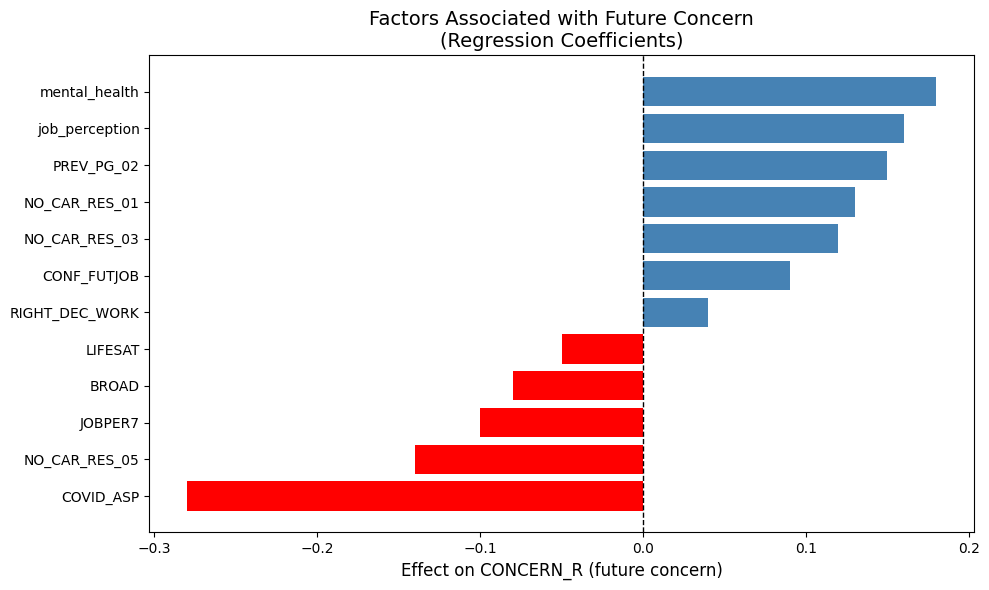

In [32]:
import matplotlib.pyplot as plt
import pandas as pd


coeff_data = pd.DataFrame({
    'Variable': ['COVID_ASP', 'mental_health', 'job_perception', 'PREV_PG_02',
                 'NO_CAR_RES_01', 'NO_CAR_RES_03', 'NO_CAR_RES_05',
                 'CONF_FUTJOB', 'JOBPER7', 'BROAD', 'LIFESAT', 'RIGHT_DEC_WORK'],
    'Coefficient': [-0.28, 0.18, 0.16, 0.15, 0.13, 0.12, -0.14, 0.09, -0.10, -0.08, -0.05, 0.04]
})


coeff_data = coeff_data.sort_values('Coefficient')

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'steelblue' for x in coeff_data['Coefficient']]
plt.barh(coeff_data['Variable'], coeff_data['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Effect on CONCERN_R (future concern)', fontsize=12)
plt.title('Factors Associated with Future Concern\n(Regression Coefficients)', fontsize=14)
plt.tight_layout()
plt.show()

## 📌 Summary

### Objective
This project aimed to identify the key factors associated with young people’s anxiety about their future careers using data from the ASPIRES3 longitudinal study (N = 7,635, ages 21‑22 in England).

### Methods
After extensive data cleaning, feature engineering (including creating `mental_health` and `job_perception` composites), and variable selection, a linear regression model was built and validated. Multicollinearity was checked using VIF, and model generalizability was assessed with 5‑fold cross‑validation.

### Key Findings
- The final model explains **40.2%** of the variance in future concern (adjusted R² = 39.9%).
- All 12 predictors are statistically significant (p < 0.05) and show no multicollinearity (all VIFs < 1.6).
- The strongest unique contributor is the impact of COVID‑19 on aspirations (`COVID_ASP`), followed by:
  - Mental health (`mental_health`)
  - Job perceptions (`job_perception`)
  - Financial worry about postgraduate study (`PREV_PG_02`)
  - Career confidence (`CONF_FUTJOB`)
  - Access to careers advice (`NO_CAR_RES_*` variables)
- Cross‑validation confirmed model stability (CV R² = 0.389 ± 0.03).

### Limitations
- Cross‑sectional data prevents causal inference.
- Sample reduced to ~3,000 due to missing data.
- Self‑report measures may introduce bias.
- Findings may not generalize beyond the UK or this age group.

### Recommendations for EdTech
- **Boost career confidence** through success stories, skill‑building, and clear career pathways.
- **Improve job perceptions** by showcasing positive graduate outcomes and offering career exploration tools.
- **Integrate mental health support** (e.g., well‑being resources, stress management).
- **Make careers advice easily accessible** and reduce barriers like difficulty accessing support.
- **Address financial concerns** by highlighting scholarship options and earning potential of different careers.

### Next Steps
Future work could explore longitudinal changes, test interventions, or use qualitative methods to deepen understanding.